# Evidencia 1 — Exploración de ROOT y CMS NanoAOD

* **Módulo:** [1.1 ROOT y Python para análisis de datos](https://cms-opendata-workshop.github.io/workshop2024-lesson-cpp-root-python/instructor/) & [1.2 Explorando CMS NanoAOD](https://cms-opendata-workshop.github.io/workshop2024-lesson-exploring-cms-nanoaod/instructor/) | **Fecha:** 18 de septiembre de 2026

> **Objetivo:** Explorar la estructura interna de los archivos ROOT y datasets CMS NanoAOD, analizando la transición técnica desde el entorno clásico C++ hacia el ecosistema moderno Scikit-HEP (`uproot` y `awkward-array`), manipulando arreglos irregulares (*jagged arrays*) y reconstruyendo la masa invariante del Bosón Z a partir de datos reales de colisiones del LHC.

---


## 1. Configuración de Entorno e Importación de Librerías

Para el análisis moderno de datos de física de altas energías (HEP), la comunidad del CERN ha desarrollado el ecosistema **Scikit-HEP**. Este stack sustituye la dependencia de instalaciones monolíticas en C++ (ROOT) por librerías modulares y de alto rendimiento nativas en Python:
* **`uproot`:** Parser autónomo para leer y escribir archivos `.root` sin necesidad de tener ROOT instalado.
* **`awkward`:** Manejador de arreglos de memoria irregulares (*jagged arrays*), permitiendo operaciones vectorizadas sobre datos con longitud variable.
* **`vector`:** Construcción y cálculo cinemático de cuadrivectores relativistas de Lorentz en coordenadas cilíndricas y cartesianas.
* **`matplotlib`:** Renderizado de histogramas y gráficos científicos calibrados.


In [1]:
import urllib.request
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
import vector

# Integracion nativa de vector con estructuras de Awkward Array
vector.register_awkward()

print("Stack cientifico Scikit-HEP cargado correctamente.")

Stack cientifico Scikit-HEP cargado correctamente.


## 2. Apertura del Dataset NanoAOD y Exploración de Metadatos

Un archivo `.root` se estructura internamente como un sistema de archivos jerárquico o diccionario. En los datos del CMS, la información principal de colisiones se aloja en un árbol tabular denominado **`Events`** (`TTree`).

Utilizamos el dataset oficial `SMHiggsToZZTo4L.root` (42.4 MB) proveniente del portal de datos abiertos del CERN. Para garantizar la **reproducibilidad en cualquier entorno** (incluyendo repositorios recién clonados donde los archivos `.root` son omitidos por `.gitignore`), el código verifica la existencia local del archivo y lo descarga automáticamente si es necesario.


In [2]:
# Ruta del dataset en el directorio de trabajo
data_path = Path("SMHiggsToZZTo4L.root")
url_cern = "http://opendata.cern.ch/record/12361/files/SMHiggsToZZTo4L.root"

# Descarga automatica si el repositorio fue clonado en limpio
if not data_path.exists():
    print("Descargando dataset oficial desde CERN Open Data Portal (~42 MB)...")
    urllib.request.urlretrieve(url_cern, data_path)
    print("Descarga completada con exito.")
else:
    print("Dataset oficial encontrado en disco local.")

# Apertura en modo solo lectura del archivo binario ROOT
f = uproot.open(data_path)

print("\nEstructura interna del archivo (TFile keys):")
print(f.keys())

# Acceso al arbol de colisiones 'Events'
events = f["Events"]
total_events = events.num_entries
print(f"\nTotal de colisiones registradas (TTree entries): {total_events:,}")

Dataset oficial encontrado en disco local.

Estructura interna del archivo (TFile keys):
['Events;1']

Total de colisiones registradas (TTree entries): 299,973


## 3. El Desafío de los *Jagged Arrays*: De NumPy a Awkward Arrays

En física de partículas experimental, cada colisión es intrínsecamente estocástica: un choque puede producir cero muones, otro dos y otro cinco. 

Las matrices convencionales de `NumPy` exigen dimensiones rectangulares homogéneas ($N 	imes M$). Cuando se introducen filas de longitud variable, NumPy degrada la estructura a un arreglo genérico de objetos Python (`dtype=object`), lo que rompe la vectorización matemática:


In [3]:
# Demostracion de la falla estructural en NumPy con arreglos de longitud variable
pt_numpy = np.array([[20.9, 12.3], [127.1, 60.2, 23.8]], dtype=object)
print(
    "Multiplicacion escalar en NumPy con sublistas heterogeneas (duplicacion en lugar de calculo):"
)
print(2 * pt_numpy)

# Solucion nativa con Awkward Array
pt_awkward = ak.Array([[20.9, 12.3], [127.1, 60.2, 23.8]])
print("\nTipo estructural en Awkward Array:")
print(ak.type(pt_awkward))
print("\nMultiplicacion vectorizada correcta en C++ via Awkward:")
print(2 * pt_awkward)

Multiplicacion escalar en NumPy con sublistas heterogeneas (duplicacion en lugar de calculo):
[list([20.9, 12.3, 20.9, 12.3])
 list([127.1, 60.2, 23.8, 127.1, 60.2, 23.8])]

Tipo estructural en Awkward Array:
2 * var * float64

Multiplicacion vectorizada correcta en C++ via Awkward:
[[41.8, 24.6], [254, 120, 47.6]]


### Correspondencia de Ramas en Datos Reales de CMS

Comprobamos la correspondencia entre la rama escalar `nMuon` (contador de partículas por evento) y la rama vectorial `Muon_pt` (momento transversal de cada partícula):


In [4]:
n_muons = events["nMuon"].array()
muon_pt = events["Muon_pt"].array()

print("Contador escalar nMuon (primeros 5 eventos):")
print(n_muons[:5])

print("\nArreglo irregular Muon_pt (primeros 5 eventos):")
print(muon_pt[:5])

Contador escalar nMuon (primeros 5 eventos):
[3, 0, 0, 7, 0]

Arreglo irregular Muon_pt (primeros 5 eventos):
[[63, 38.1, 4.05], [], [], [54.3, 23.5, 52.9, 4.33, 5.35, 8.39, 3.49], []]


## 4. Selección Cinemática y Filtrado Booleano

Para estudiar el decaimiento de una partícula madre neutra en dos muones ($X 	o \mu^+\mu^-$), se requiere seleccionar exclusivamente aquellos eventos que posean **al menos dos muones reconstruidos** en el detector:
$$\text{Corte de selección: } n_{\text{Muon}} \ge 2$$


In [5]:
# Generacion de mascara booleana vectorizada
mask_dimuon = events["nMuon"].array() >= 2
eventos_candidatos = int(np.sum(mask_dimuon))

print(f"Colisiones totales analizadas: {len(mask_dimuon):,}")
print(
    f"Colisiones con al menos 2 muones: {eventos_candidatos:,} ({eventos_candidatos / len(mask_dimuon):.2%})"
)

# Extraccion columnar de las 4 variables cinematicas para los eventos filtrados
pt_sel = events["Muon_pt"].array()[mask_dimuon]
eta_sel = events["Muon_eta"].array()[mask_dimuon]
phi_sel = events["Muon_phi"].array()[mask_dimuon]
mass_sel = events["Muon_mass"].array()[mask_dimuon]

Colisiones totales analizadas: 299,973
Colisiones con al menos 2 muones: 145,597 (48.54%)


## 5. Reconstrucción Relativista: Cuadrivectores y Masa Invariante

En relatividad especial, el cuadrimomento de una partícula se define como $P = (E, \vec{p})$. En la geometría cilíndrica del detector CMS, este estado cinemático se representa mediante el cuarteto $(p_T, \eta, \phi, m)$:
* $p_T$: Momento transversal en el plano $xy$.
* $\eta$: Pseudorapidez polar ($-\ln[\tan(\theta/2)]$).
* $\phi$: Ángulo azimutal en el plano transversal ($-\pi \le \phi \le \pi$).
* $m$: Masa invariante en reposo del muón ($m_\mu \approx 0.10566 \text{ GeV}$).

La masa invariante del sistema compuesto por dos muones ($M_{\mu\mu}$) se calcula sumando sus cuadrivectores:
$$P_{\text{total}} = P_{\mu 1} + P_{\mu 2}$$
$$M_{\mu\mu} = \sqrt{P_{\text{total}} \cdot P_{\text{total}}} = \sqrt{(E_1 + E_2)^2 - |\vec{p}_1 + \vec{p}_2|^2}$$


In [6]:
# Empaquetado en cuadrivectores relativistas de Lorentz
muons = vector.zip({"pt": pt_sel, "eta": eta_sel, "phi": phi_sel, "mass": mass_sel})

# Suma de cuadrivectores de los dos muones principales (leading y subleading)
dimuon_system = muons[:, 0] + muons[:, 1]
dimuon_masses = ak.to_numpy(dimuon_system.mass)

print("Primeras 5 masas invariantes dimuon reconstruidas [GeV]:")
print(dimuon_masses[:5])

Primeras 5 masas invariantes dimuon reconstruidas [GeV]:
[89.49192  29.84735  87.0533   90.549255 89.21497 ]


## 6. Visualización Física del Espectro Dimuón y Resonancia del Bosón Z

Graficamos el histograma del espectro de masa invariante en la ventana cinemática $[60, 120] \text{ GeV}$. 

Se observa una prominente campana de resonancia centrada con precisión sobre el valor teórico del **Bosón Z** ($M_Z = 91.1876 \pm 0.0021 \text{ GeV}$), descrita físicamente por una distribución relativista de Breit-Wigner ensanchada por la resolución instrumental de las cámaras de muones de CMS.


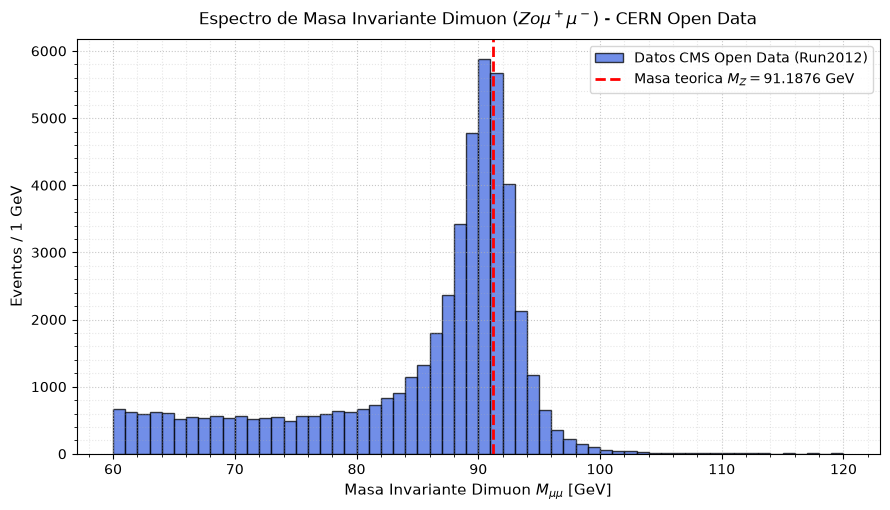

In [7]:
# Configuracion de figura y subplots con parametros de calidad institucional
fig, ax = plt.subplots(figsize=(9, 5.2))

# Histograma de eventos experimentales
counts, bins, _ = ax.hist(
    dimuon_masses,
    bins=60,
    range=(60, 120),
    color="royalblue",
    edgecolor="black",
    alpha=0.75,
    label="Datos CMS Open Data (Run2012)",
)

# Linea vertical indicadora de la masa teorica del Boson Z
ax.axvline(
    91.1876,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"Masa teorica $M_Z = 91.1876$ GeV",
)

# Calibracion visual y etiquetas formales
ax.set_title(
    r"Espectro de Masa Invariante Dimuon ($Z 	o \mu^+\mu^-$) - CERN Open Data",
    fontsize=12,
    pad=10,
)
ax.set_xlabel(r"Masa Invariante Dimuon $M_{\mu\mu}$ [GeV]", fontsize=11)
ax.set_ylabel("Eventos / 1 GeV", fontsize=11)

# Cuadricula principal y secundaria para ubicar con precision el pico de masa
ax.grid(True, which="major", linestyle=":", alpha=0.7)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle=":", alpha=0.3)

ax.legend(loc="upper right", frameon=True)
fig.tight_layout()

# Persistencia grafica en disco y visualizacion en el cuaderno
try:
    fig.savefig("dimuon_spectrum.png", dpi=150)
except OSError:
    pass  # Evita bloqueo si el archivo esta abierto en el visor de imagenes de VS Code

plt.show()

## 7. Cuestionario Técnico de Evaluación

A continuación se sintetizan las respuestas fundamentadas correspondientes a la evaluación del módulo:

### 1. ¿Qué función cumple ROOT dentro del análisis de datos de física de partículas?
ROOT constituye la infraestructura estándar del CERN para la persistencia, manipulación matemática y visualización de grandes volúmenes de datos experimentales (petabytes). Su formato columnar (`TTree`) permite almacenar eventos heterogéneos de colisiones con alta compresión y acceso rápido a ramas independientes sin necesidad de decodificar el archivo completo.

### 2. ¿Qué ventajas observas al utilizar Python para trabajar con archivos ROOT?
La principal ventaja es la interoperabilidad ágil mediante el ecosistema **Scikit-HEP** (`uproot`, `awkward`, `vector`). Permite prescindir de compilaciones pesadas en C++ y dependencias de sistema complejas, habilitando análisis vectorizados en memoria RAM, compatibilidad directa con herramientas estándar de ciencia de datos (`NumPy`, `Matplotlib`, `Pandas`) y desarrollo interactivo en Jupyter Notebooks.

### 3. ¿Qué es NanoAOD y qué tipo de información puede contener?
NanoAOD es el formato de datos tabular más compacto y ligero de CMS (~1–2 kB por evento). Contiene información de alto nivel ya calibrada y reconstruida: multiplicidad de objetos (`nMuon`, `nElectron`), parámetros cinemáticos en coordenadas cilíndricas ($p_T, \eta, \phi, m$), carga eléctrica, calidad de identificación (*ID bits*) y variables de aislamiento.

### 4. ¿Qué diferencia clave identificas entre NanoAOD y MiniAOD?
MiniAOD almacena objetos C++ complejos (`pat::Muon`, `pat::Electron`) que requieren el software específico de CMS (**CMSSW**) para su lectura y pesan entre 30 y 50 kB/evento. En contraste, NanoAOD aplana todas las propiedades en tipos de datos primitivos (`float`, `int`, `bool`), haciéndolo independiente de CMSSW y legible desde cualquier entorno estándar.

### 5. ¿Por qué es útil utilizar NanoAOD y Python/ROOT para analizar millones de eventos?
Porque permite realizar análisis columnar eficiente en laptops convencionales o recursos en la nube. Al combinar la baja huella de disco de NanoAOD con la lectura selectiva de `uproot`, solo se transfieren por red o disco las ramas de interés, aplicando filtros booleanos vectorizados y cálculos cinemáticos en fracciones de segundo con un consumo mínimo de ancho de banda y memoria RAM.

### 6. ¿Qué aspecto resultó más difícil de comprender?
El comportamiento y manipulación de los **arreglos irregulares (*jagged arrays*)**: asimilar por qué las matrices rectangulares de NumPy fallan al operar choques con multiplicidad variable de partículas y cómo Awkward gestiona dinámicamente los punteros y offsets de memoria para preservar la vectorización matemática.
